# Density of states using tensor networks

Here we provide an example of how to compute density of states (DOS) of Fibonacci, Tribonacci and silver-mean chains.

In [432]:
using ITensorMPS
using ITensors
include("../src/TensorQuasicrystals.jl")
using .TensorQuasicrystals
using Plots

## Construction of the Hamiltonian operators

Construciton of the diagonal and off-diagonal Fiboancci Hamiltonians as well as off-diagonal silver-mean and Tribonacci Hamiltonians. In addition, there exists methods for construction diagonal silver-mean and Tribonacci Hamiltonian. All constucted models have open boundary conditions. For Fibonacci model, use boundary = :PBC to get periodic boundary conditions.

In [433]:
# sequence parameters
A = 1
B = 2
C = 3

# constant term
c_term = 4

# length of the tensor network
L = 5


H_diag, sites_diag = TensorQuasicrystals.fibonacci_diag_Hamiltonian(L, A, B; boundary = :OBC, const_term = c_term)
H_off, sites_off = TensorQuasicrystals.fibonacci_off_diag_Hamiltonian(L, A, B; boundary = :OBC, const_term = c_term)
H_off_sm, sites_off_sm = TensorQuasicrystals.sm_off_diag_Hamiltonian(L, A, B; const_term = c_term)
H_off_trib, sites_off_trib = TensorQuasicrystals.tribonacci_off_diag_Hamiltonian(L, A, B, C; const_term = c_term)


(MPO(5), Index{Int64}[(dim=2|id=749|"Qubit,Site,n=1"), (dim=2|id=365|"Qubit,Site,n=2"), (dim=2|id=974|"Qubit,Site,n=3"), (dim=2|id=964|"Qubit,Site,n=4"), (dim=2|id=313|"Qubit,Site,n=5")])

To check the construction, the matrix representation of the Hamiltonian can be obtained as follows. Use only for small system sizes.

In [434]:
TensorQuasicrystals.get_matrix_fib(H_diag, L, sites_diag)

13×13 Matrix{Float64}:
 1.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 4.0  2.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  4.0  1.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  4.0  1.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  4.0  2.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  4.0  1.0  4.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  4.0  2.0  4.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  4.0  1.0  4.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0  1.0  4.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0  2.0  4.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0  1.0  4.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0  1.0  4.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  4.0  2.0

## Kernel Polynomial Method

Tensorized kernel polynomial method for computing the DOS of an MPO Hamiltonian. Use symbol :fib, :sm or :trib to specify the used model.

k=200, maxlinkdim=12
k=200, maxlinkdim=56
k=200, maxlinkdim=16


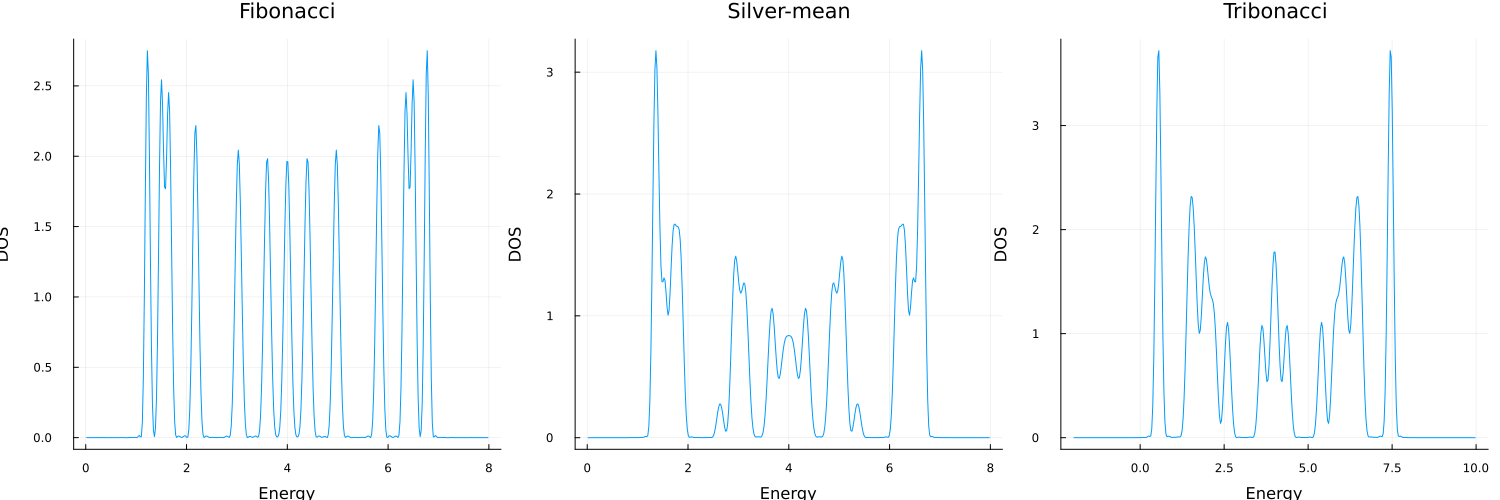

In [441]:
# number of moments
Nmu = 200
# energy resolution
Eres = 400
# energy range for the off-diagonal Fibonacci and silver-mean Hamiltonians
Ex_off = range(-2*max(A,B)+c_term, 2*max(A,B)+c_term, Eres)
# energy range for the off-diagonal Tribonacci Hamiltonian
Ex_off_trib = range(-2*max(A,B, C)+c_term, 2*max(A,B, C)+c_term, Eres)

# compute DOS
DOS_fib = TensorQuasicrystals.get_DOS(H_off, sites_off, :fib , Nmu, Ex_off)
DOS_sm = TensorQuasicrystals.get_DOS(H_off_sm, sites_off_sm, :sm , Nmu, Ex_off)
DOS_trib = TensorQuasicrystals.get_DOS(H_off_trib, sites_off_trib, :trib, Nmu, Ex_off_trib)

# plot results
p = plot(Ex_off, DOS_fib, layout=(1,3), subplot=1, size=(1500, 500), margin = 5Plots.mm; xlabel = "Energy", ylabel = "DOS", legend = :none, title="Fibonacci")
plot!(Ex_off, DOS_sm, subplot=2; xlabel = "Energy", ylabel = "DOS", legend = :none, title="Silver-mean")
plot!(Ex_off_trib, DOS_trib, subplot=3; xlabel = "Energy", ylabel = "DOS", legend = :none, title="Tribonacci")

